# Trabalho Final — LLMs em Sistemas de Software

# **Atividade Avaliativa**  
## **Instituto de Computação** / **Universidade Estadual de Campinas**
### **Curso**: INF0087 - Sistemas Inteligentes com Agentes Autônomos usando Grandes Modelos de Linguagem
### **Disciplina**: LLMs em Sistemas de Software
### **Professor**: Prof. Dr. André Gomes Regino

### **Aluno**: Anderson Luiz Brandão de Souza
### **Data**: 18 de Junho de 2026

> **Instruções Gerais**
>
> Este trabalho deve ser entregue como um **Jupyter Notebook (.ipynb)** executado no **Google Colab**.
> Todas as células de código devem estar executadas e com os outputs visíveis no momento da entrega.
>
> - Documente seu raciocínio em células Markdown ao longo do notebook.
> - Use comentários no código para explicar decisões de implementação relevantes.
> - Certifique-se de que o notebook pode ser executado de ponta a ponta sem erros.
> - Variáveis sensíveis (API keys) devem ser carregadas via `google.colab.userdata` ou variáveis de ambiente — **nunca** expostas diretamente no código.

---
---
---

## Tema do Trabalho

Você irá construir um **sistema de perguntas e respostas baseado em RAG (Retrieval-Augmented Generation)** sobre uma base de documentos à sua escolha (exemplos: artigos técnicos, legislação, documentação de software, relatórios, etc.). O sistema deve ser construído com **LangChain**, explorar diferentes estratégias de **prompt engineering** e ser avaliado com métricas objetivas.


---
---
---


## Parte 1 — Prompt Engineering (3 pontos)

### Objetivo
Demonstrar domínio prático de diferentes técnicas de prompting e compreender como os hiperparâmetros do modelo afetam as respostas geradas.

### Tarefas

**1.1 — Comparação de estratégias de prompting**

Escolha uma tarefa de sua preferência (ex: classificação de texto, extração de informação, sumarização, geração de código) e implemente as três estratégias abaixo para a **mesma tarefa e o mesmo modelo**:

- **Zero-shot**: apenas a instrução, sem exemplos.
- **Few-shot**: instrução com 3 exemplos no prompt.
- **Chain-of-Thought (CoT)**: instrução que induz o modelo a raciocinar passo a passo antes de responder.

Para cada estratégia, execute ao menos **3 inputs diferentes** e registre as respostas.

**1.2 — Análise dos hiperparâmetros**

Usando a mesma tarefa do item 1.1, varie os seguintes parâmetros e registre o impacto observado nas respostas:

| Parâmetro     | Valores a testar         |
|---------------|--------------------------|
| `temperature` | 0.0 / 0.7 / 1.4          |
| `top_p`       | 0.5 / 0.9 / 1.0          |
| `max_tokens`  | Restritivo / Adequado / Amplo |

**1.3 — Discussão**

Em uma célula Markdown, responda:
- Qual estratégia apresentou os melhores resultados para a sua tarefa? Por quê?
- Como a variação de `temperature` impactou a consistência e criatividade das respostas?
- Quais limitações você identificou em cada abordagem?

### Critérios de Avaliação
- Implementação correta das três estratégias (1 pt)
- Experimento com hiperparâmetros documentado e com outputs visíveis (1 pt)
- Qualidade e profundidade da análise crítica (1 pt)


In [ ]:
# Parte 1 - Setup geral (reutilizado nas Partes 2 e 3)
!pip install --upgrade pip
!pip -q install groq langchain langchain-community langchain-text-splitters langchain-groq langchain-huggingface faiss-cpu sentence-transformers rouge-score pypdf pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 48.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
import os
import json
import time
from textwrap import dedent
import pandas as pd
from groq import Groq
from IPython.display import display, Markdown

In [ ]:
# Carrega chave de forma segura (Colab Secrets) com fallback para variavel de ambiente
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")
except Exception:
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("Defina GROQ_API_KEY no Colab Secrets ou nas variaveis de ambiente.")


In [ ]:
os.environ["GROQ_API_KEY"] = GROQ_API_KEY
client = Groq(api_key=GROQ_API_KEY)
MODEL_NAME = "llama-3.1-8b-instant"

def chat_groq(user_prompt, system_prompt="Voce e um assistente tecnico e objetivo.", temperature=0.2, top_p=1.0, max_tokens=300):
    """Chamada padrao ao modelo para manter reproducibilidade dos experimentos."""
    time_start = time.time()
    completion = client.chat.completions.create(
        model=MODEL_NAME,
        temperature=temperature,
        top_p=top_p,
        max_tokens=max_tokens,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
    )
    time_end = time.time()
    time_elapsed = time_end - time_start

    total_response = {
        "response": completion.choices[0].message.content.strip(),
        "usage": {
            "prompt_tokens": completion.usage.prompt_tokens,
            "completion_tokens": completion.usage.completion_tokens,
            "total_tokens": completion.usage.total_tokens,
        },
        "time": time_elapsed,

    }
    return total_response

### Resolução 1.1 - Comparação entre Zero-shot, Few-shot e Chain-of-Thought (CoT)


**Tarefa escolhida**: classificação de intenção do cliente em um atendimento do e-commerce


In [ ]:
from textwrap import dedent

labels = [
    "pagamento",
    "entrega",
    "troca_devolucao",
    "fidelidade_promocoes",
    "fora_escopo",
]

casos_teste = [
    {
        "pergunta": "Comprei com entrega super expressa. Posso usar cupom de frete gratis e cashback no mesmo pedido?",
        "labels_esperadas": ["entrega", "fidelidade_promocoes"],
    },
    {
        "pergunta": "No site oficial, da pra pagar boleto e parcelar em 12x sem juros?",
        "labels_esperadas": ["pagamento"],
    },
    {
        "pergunta": "Qual é a temperatura hoje em Juazeiro do Norte?",
        "labels_esperadas": ["fora_escopo"],
    },
]

# Prompts de teste para os modelos
inputs_teste = [c["pergunta"] for c in casos_teste]

# Few-shot com 3 exemplos
few_shot_exemplos = dedent("""
Exemplo 1
Pergunta: Posso pagar com PIX e cartao? Boleto vale no e-commerce de varejo?
Resposta JSON:
{
  "labels":["pagamento"],
  "justificativa":"Pergunta sobre meios de pagamento aceitos.",
  "confianca":"alta"
}

Exemplo 2
Pergunta: Na entrega super expressa posso aplicar frete gratis?
Resposta JSON:
{
  "labels":["entrega", "fidelidade_promocoes"],
  "justificativa":"Combina regra de modalidade de entrega com regra promocional.",
  "confianca":"alta"
}

Exemplo 3
Pergunta: Como fazer um bolo de chocolate?
Resposta JSON:
{
  "labels":["fora_escopo"],
  "justificativa":"Pergunta fora das politicas e do escopo de atendimento.",
  "confianca":"alta"
}
""")

def _instrucao_base():
    return dedent(f"""
    Voce e um classificador de intencoes de atendimento.
    Rotulos validos: {labels}

    Regras:
    1) Retorne 1 ou mais labels no campo "labels" (lista, sem repeticao).
    2) Se houver multiplas intencoes, inclua todas.
    3) Se nao houver aderencia, use ["fora_escopo"].
    4) Nao invente labels fora da lista.
    5) Retorne SOMENTE JSON valido com:
       - labels (list[str])
       - justificativa (str curta)
       - confianca ("alta"|"media"|"baixa")
    """)

def prompt_zero_shot(pergunta):
    return dedent(f"""
    {_instrucao_base()}

    Classifique:
    {pergunta}
    """)

def prompt_few_shot(pergunta):
    return dedent(f"""
    {_instrucao_base()}

    Siga os exemplos:
    {few_shot_exemplos}

    Agora classifique:
    {pergunta}
    """)

def prompt_cot(pergunta):
    return dedent(f"""
    {_instrucao_base()}

    Pense em 3 passos curtos (internamente) antes de decidir.
    Inclua seu raciocinio detalahdo no campo 'justificativa'.
    Depois retorne APENAS o JSON final.

    Pergunta:
    {pergunta}
    """)

print("Setup concluido.")
print(f"Modelo em uso: {MODEL_NAME}")
print(f"Total de labels: {len(labels)}")
print(f"Total de prompts de teste: {len(inputs_teste)}")

Setup concluido.
Modelo em uso: llama-3.1-8b-instant
Total de labels: 5
Total de prompts de teste: 3


In [ ]:
estrategias = {
    "zero_shot": prompt_zero_shot,
    "few_shot": prompt_few_shot,
    "chain_of_thought": prompt_cot,
}

registros = []
for pergunta in inputs_teste:
    for nome_estrategia, fn_prompt in estrategias.items():
        resposta = chat_groq(
            fn_prompt(pergunta),
            system_prompt="Voce é um classificador de intencao para e-commerce.",
            temperature=0.3,
            top_p=0.5,
            max_tokens=500,
        )
        registros.append({
            "pergunta": pergunta,
            "estrategia": nome_estrategia,
            "resposta_modelo": resposta["response"],
            "prompt_tokens": resposta["usage"]["prompt_tokens"],
            "completion_tokens": resposta["usage"]["completion_tokens"],
            "total_tokens": resposta["usage"]["total_tokens"],
            "time": resposta["time"],
        })

In [ ]:
df_prompting = pd.DataFrame(registros)
display(df_prompting[["estrategia", "prompt_tokens", "completion_tokens", "total_tokens", "time"]].groupby(["estrategia"]).sum())

,prompt_tokens,completion_tokens,total_tokens,time
estrategia,,,,
chain_of_thought,853,357,1210,0.976114
few_shot,1333,139,1472,0.646966
zero_shot,700,333,1033,0.961080


In [ ]:
for _, row in df_prompting.iterrows():
    print("=" * 100)
    print(f"Pergunta: {row['pergunta']}")
    print(f"Estrategia: {row['estrategia']}")
    print("Resposta:")
    print(row["resposta_modelo"])

Pergunta: Comprei com entrega super expressa. Posso usar cupom de frete gratis e cashback no mesmo pedido?
Estrategia: zero_shot
Resposta:
```json
{
  "labels": ["entrega", "fidelidade_promocoes"],
  "justificativa": "Pergunta sobre entrega e uso de cupom de frete gratis e cashback",
  "confianca": "alta"
}
```

A classificação foi feita com base nas seguintes razões:

- A pergunta está relacionada à entrega, pois o cliente está perguntando sobre a possibilidade de usar cupom de frete gratis e cashback no mesmo pedido, o que está relacionado à entrega do produto.
- A pergunta também está relacionada à fidelidade e promoções, pois o cliente está perguntando sobre a possibilidade de usar cupom de frete gratis e cashback, o que é uma promoção oferecida pela empresa para recompensar os clientes leais.

A confiança foi classificada como "alta" porque a pergunta é clara e direta, e não há nenhuma ambiguidade ou dúvida sobre o que o cliente está perguntando.
Pergunta: Comprei com entrega supe

### Resolução 1.2 - Analise de hiperparâmetros


In [ ]:
pergunta_base = "Comprei com entrega super expressa. Posso usar cupom de frete gratis e cashback no mesmo pedido?"
cenarios = [
    {"parametro": "temperature", "valor": "0.0", "temperature": 0.0, "top_p": 0.9, "max_tokens": 250},
    {"parametro": "temperature", "valor": "0.7", "temperature": 0.7, "top_p": 0.9, "max_tokens": 250},
    {"parametro": "temperature", "valor": "1.4", "temperature": 1.4, "top_p": 0.9, "max_tokens": 250},
    {"parametro": "top_p", "valor": "0.5", "temperature": 0.7, "top_p": 0.5, "max_tokens": 250},
    {"parametro": "top_p", "valor": "0.9", "temperature": 0.7, "top_p": 0.9, "max_tokens": 250},
    {"parametro": "top_p", "valor": "1.0", "temperature": 0.7, "top_p": 1.0, "max_tokens": 250},
    {"parametro": "max_tokens", "valor": "restritivo(50)", "temperature": 0.7, "top_p": 0.9, "max_tokens": 50},
    {"parametro": "max_tokens", "valor": "adequado(250)", "temperature": 0.7, "top_p": 0.9, "max_tokens": 250},
    {"parametro": "max_tokens", "valor": "amplo(500)", "temperature": 0.7, "top_p": 0.9, "max_tokens": 500},
]

registros_hp = []
for c in cenarios:
    resposta = chat_groq(
        prompt_zero_shot(pergunta_base),
        system_prompt="Voce e um classificador de intencao para e-commerce.",
        temperature=c["temperature"],
        top_p=c["top_p"],
        max_tokens=c["max_tokens"],
    )
    registros_hp.append({
        "parametro": c["parametro"],
        "valor_testado": c["valor"],
        "temperature": c["temperature"],
        "top_p": c["top_p"],
        "max_tokens": c["max_tokens"],
        "tamanho_resposta_chars": len(resposta["response"]),
        "resposta_modelo": resposta["response"],
    })

df_hiperparametros = pd.DataFrame(registros_hp)
display(Markdown("### Resultados - Analise de Hiperparametros"))
display(df_hiperparametros[[
    "parametro", "valor_testado", "temperature", "top_p", "max_tokens", "tamanho_resposta_chars"
]])

display(Markdown("### Amostra de Respostas"))
for _, row in df_hiperparametros.iterrows():
    print("-" * 100)
    print(f"{row['parametro']} = {row['valor_testado']}")
    print(row["resposta_modelo"])

### Resultados - Analise de Hiperparametros

,parametro,valor_testado,temperature,top_p,max_tokens,tamanho_resposta_chars
0,temperature,0.0,0.0,0.9,250,411
1,temperature,0.7,0.7,0.9,250,622
2,temperature,1.4,1.4,0.9,250,597
3,top_p,0.5,0.7,0.5,250,492
4,top_p,0.9,0.7,0.9,250,427
5,top_p,1.0,0.7,1.0,250,791
6,max_tokens,restritivo(50),0.7,0.9,50,163
7,max_tokens,adequado(250),0.7,0.9,250,658
8,max_tokens,amplo(500),0.7,0.9,500,568


### Amostra de Respostas

----------------------------------------------------------------------------------------------------
temperature = 0.0
```json
{
  "labels": ["entrega", "fidelidade_promocoes"],
  "justificativa": "Pergunta sobre uso de cupom de frete gratis e cashback no mesmo pedido",
  "confianca": "alta"
}
```

Justificativa: A pergunta sobre uso de cupom de frete gratis e cashback no mesmo pedido está relacionada à entrega e fidelidade/promoções, pois o cliente está perguntando sobre a possibilidade de usar esses benefícios em conjunto.
----------------------------------------------------------------------------------------------------
temperature = 0.7
```json
{
  "labels": [
    "entrega",
    "fidelidade_promocoes"
  ],
  "justificativa": "Pedido contém questões sobre entrega e benefícios de fidelidade",
  "confianca": "alta"
}
```

Explicação:

- A intenção "entrega" é relacionada à questão da entrega super expressa.
- A intenção "fidelidade_promocoes" é relacionada à possibilidade de usar cup

### Resolução 1.3 - Discussão dos resultados

- **Qual estratégia apresentou os melhores resultados para a sua tarefa? Por quê?**

Ambas as estratégias: zero-shot, few-shot, chain-of-thought apresentaram os mesmos resultados e todos coerentes com as respostas esperadas na tarefa de classificação de intenção de antedimento. Pois trata-se de uma tarefa simples e com especificações bem-definidas.  

Porém, a estratégia **few-shot** foi a única a seguir estritamente o formato de output json. Como em um sistema real em produção, a validação de output é algo fundamental nas integrações, essa seria a escolha mais prática e segura.

Além disso, julgo importante avaliarmos, não somente as respostas, mas também o custo e o tempo de inferência. Mas não houve discrepâncias relevantes entre os três métodos.

- **Como a variação de `temperature` impactou a consistência e criatividade das respostas?**

O aumento do parâmetro `temperature` prejudicou a qualidade das respostas, pois gerou justificativas e explicações muito longas, quebrando o formato json esperado. O aumento de `top_p` e `max_tokens` resultaram em um efeito similar: resposta muito mais verbosa, sem consistência e fora do padrão json. Contudo, `max_tokens = 50` (muito restritivo) foi um valor muito baixo, que truncou uma parte importante da resposta.

Portanto, a combinação ideal é:
> - `temperature`: 0.0
> - `top_p`: 0.5
> - `max_tokens`: ~ 100-150

Para fazer uma análise mais profunda e precisa em um ambiente real, deveríamos testar com mais exemplos, e não somente 3 como pedido aqui na avaliação.

- **Quais limitações você identificou em cada abordagem?**

Como citado anterior, devido a ausência de exemplos de input-output, as estratégias de zero-shot e chain-of-thought falharam na formatação do output em json. Isso pode ser corrigido usando formatador `JsonOutputParser` do LangChain. Que será usado nas próximas seções.

***

## Parte 2 — Construção do Pipeline RAG com LangChain (3,5 pontos)

### Objetivo
Construir um pipeline RAG completo e funcional utilizando LangChain, integrando carregamento de documentos, chunking, embeddings, banco vetorial e recuperação.

### Tarefas

**2.1 — Preparação da base de dados**

- Escolha uma coleção de documentos (mínimo de **3 arquivos** em PDF, TXT ou CSV).
- Carregue os documentos utilizando os **Document Loaders** do LangChain.
- Aplique **uma estratégia de chunking** (ex: `RecursiveCharacterTextSplitter` com tamanhos distintos, ou `CharacterTextSplitter` ou chunking por parágrafo) e justifique a escolha final.

**2.2 — Indexação vetorial**

- Gere embeddings com um modelo à sua escolha (ex: OpenAI `text-embedding-ada-002`, HuggingFace `sentence-transformers`, etc.).
- Indexe os chunks em um banco vetorial (FAISS, Chroma ou Pinecone).
- Demonstre uma busca de similaridade direta no banco vetorial com ao menos **2 queries de teste**, exibindo os chunks recuperados.

**2.3 — Pipeline de geração**

- Monte uma chain de RAG com LangChain (`RetrievalQA` ou `ConversationalRetrievalChain`) que:
  - Recupere os `top-k` chunks mais relevantes (experimente ao menos dois valores de `k`).
  - Injete o contexto recuperado em um prompt estruturado.
  - Gere a resposta final com o LLM de sua escolha.
- Execute ao menos **3 perguntas** sobre a sua base de documentos e exiba as respostas com os respectivos trechos de contexto utilizados.

### Critérios de Avaliação
- Carregamento, chunking e indexação corretos e justificados (1,5 pt)
- Pipeline RAG funcional com contexto injetado corretamente (1,5 pt)
- Diversidade de queries testadas e clareza nos outputs (0,5 pt)

***


### Resolução 2.1 - Preparação da base de dados

**Contexto**: o objetivo dessa avaliação é construir um assistente de atendimento de um ecommerce, usando as técnicas de RAG aprendidas nesse curso. Como eu trabalho no Grupo Boticário, escolhi  simular esse cenário e os seguintes documentos para compor a base de conhecimento:

- **`faq_ecommerce.pdf`**: perguntas e respostas frequentes dos consumidores sobre formas de pagamento, entrega, políticas de reembolso e cashback. Informações reais retiradas dos sites oficiais.
- **`preco_estoque.csv`**: simulação de dados de preço e estoque para uma lista de 20 produtos. Os dados verdadeiros confidenciais e muito mais volumosos.
- **`revenda.txt`**: como se tornar uma pessoas revendedora da marca e quais são as vantagens e benefícios.

> - Os arquivos serão enviados junto com esse Colab do trabalho final.

> - Faça o upload desses arquivos na pasta `knowlegde_base` no mesmo ambiente do Colab.

Todos esses dados listados acima são muito específicos e detalhados sobre a operação / atendimento da marca O Boticário. Logo, um modelo LLM "puro" não teria acesso as essas informações. Daí, para a construção do assistente de atendimento, faz-se necessário criar um sistema RAG para alimentar com esses dados importantes.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

base_kb = Path("knowlegde_base")
arquivos_kb = sorted([p.name for p in base_kb.glob("*") if p.is_file()])

print("Arquivos encontrados na base de conhecimento:")
for a in arquivos_kb:
    print(f"- {a}")

tipos = sorted({p.suffix.lower() for p in base_kb.glob('*') if p.is_file()})
print(f"\nTipos detectados: {tipos}")
assert ".txt" in tipos and ".csv" in tipos and ".pdf" in tipos, "A base deve conter .txt, .csv e .pdf"

Arquivos encontrados na base de conhecimento:
- faq_ecommerce.pdf
- preco_estoque.csv
- revenda.txt

Tipos detectados: ['.csv', '.pdf', '.txt']


**Reuso de configuração do modelo**: reaproveitando os mesmos client e modelo configurado na Parte 1 para manter consistência experimental durante a avaliação.

In [ ]:
# Configuracao defensiva: recria cliente apenas se necessario
if "GROQ_API_KEY" not in globals() or not GROQ_API_KEY:
    try:
        from google.colab import userdata
        GROQ_API_KEY = userdata.get("GROQ_API_KEY")
    except Exception:
        GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY nao encontrada. Configure antes de continuar.")

os.environ["GROQ_API_KEY"] = GROQ_API_KEY

if "client" not in globals():
    client = Groq(api_key=GROQ_API_KEY)

if "MODEL_NAME" not in globals():
    MODEL_NAME = "llama-3.1-8b-instant"

print("Configuracao pronta para o pipeline RAG.")
print(f"Modelo de geracao: {MODEL_NAME}")

Configuracao pronta para o pipeline RAG.
Modelo de geracao: llama-3.1-8b-instant


#### Carregamento dos arquivos com Document Loaders

O DirectoryLoader percorre uma pasta e carrega todos os arquivos que correspondem ao padrão glob (neste caso, *.txt, *.csv e *.pdf). Cada arquivo é convertido em um objeto Document do LangChain, que contém o texto (page_content) e metadados (metadata).

In [ ]:
from langchain_community.document_loaders import TextLoader, CSVLoader, PyPDFLoader

txt_docs, csv_docs, pdf_docs = [], [], []

for fp in sorted(base_kb.glob("*.txt")):
    docs = TextLoader(str(fp), encoding="utf-8").load()
    for d in docs:
        d.metadata["tipo_fonte"] = "txt"
    txt_docs.extend(docs)

for fp in sorted(base_kb.glob("*.csv")):
    docs = CSVLoader(file_path=str(fp), encoding="utf-8").load()
    for d in docs:
        d.metadata["tipo_fonte"] = "csv"
    csv_docs.extend(docs)

for fp in sorted(base_kb.glob("*.pdf")):
    docs = PyPDFLoader(str(fp)).load()
    for d in docs:
        d.metadata["tipo_fonte"] = "pdf"
    pdf_docs.extend(docs)

documentos = pdf_docs + txt_docs + csv_docs

print(f"TXT carregados: {len(txt_docs)}")
print(f"CSV carregados: {len(csv_docs)}")
print(f"PDF (paginas) carregadas: {len(pdf_docs)}")
print(f"Total de documentos LangChain: {len(documentos)}")

for i, doc in enumerate(txt_docs[:3], start=1):
    source = doc.metadata.get("source", "sem_fonte")
    tipo = doc.metadata.get("tipo_fonte", "desconhecido")
    print("-" * 90)
    print(f"Doc {i} | tipo={tipo} | source={source}")
    print(doc.page_content[:220].replace("\n", " ") + "...")

for i, doc in enumerate(pdf_docs[:3], start=1):
    source = doc.metadata.get("source", "sem_fonte")
    tipo = doc.metadata.get("tipo_fonte", "desconhecido")
    print("-" * 90)
    print(f"Doc {i} | tipo={tipo} | source={source}")
    print(doc.page_content[:220].replace("\n", " ") + "...")

for i, doc in enumerate(csv_docs[:3], start=1):
    source = doc.metadata.get("source", "sem_fonte")
    tipo = doc.metadata.get("tipo_fonte", "desconhecido")
    print("-" * 90)
    print(f"Doc {i} | tipo={tipo} | source={source}")
    print(doc.page_content[:220].replace("\n", " ") + "...")

/tmp/ipykernel_997/3807205530.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader, CSVLoader, PyPDFLoader


TXT carregados: 1
CSV carregados: 20
PDF (paginas) carregadas: 4
Total de documentos LangChain: 25
------------------------------------------------------------------------------------------
Doc 1 | tipo=txt | source=knowlegde_base/revenda.txt
Quer revender Boticário? Conheça 5 benefícios! Descubra as vantagens de revender produtos do Boticário e aproveite a oportunidade de começar o ano com uma renda extra!  O começo de um novo ano traz aquela vontade de cria...
------------------------------------------------------------------------------------------
Doc 1 | tipo=pdf | source=knowlegde_base/faq_ecommerce.pdf
FAQ  de  E-commerce  O  Boticário    Pergunta  1:  Quais  são  os  meios  e  formas  de  pagamento  aceitos  para   compras   realizadas   no   e-commerce   d'O   Boticário?  Resposta :  As  compras  efetuadas  diretamen...
------------------------------------------------------------------------------------------
Doc 2 | tipo=pdf | source=knowlegde_base/faq_ecommerce.pdf
Pergunta 

#### Configuração do chunking

Usando `RecursiveCharacterTextSplitter` com overlap por ser uma estratégia robusta para dados heterogêneos (TXT/CSV/PDF), preservando mais contexto entre chunks adjacentes e reduzindo perda de informação em limites de corte.

> `RecursiveCharacterTextSplitter` vs. `CharacterTextSplitter`

> A escolha por `RecursiveCharacterTextSplitte` segue pelos motivos:
> - **Preservação da Semântica**: enquanto o `CharacterTextSplitter` divide o texto de forma rígida baseado em um único caractere (podendo cortar frases e ideias ao meio), o `RecursiveCharacterTextSplitter` tenta manter o texto unido o máximo possível;
> - **Hierarquia de Separadores**: utiliza uma "cascata" de separadores (como \n\n para parágrafos, \n para linhas e espaços para palavras). Se um chunk for muito grande para o limite definido, ele tenta o próximo separador da lista, o que resulta em fragmentos mais naturais e legíveis para o modelo.

#### Teste: valores ideais dos parâmetros de chunking

**Escolha de `chunk_size` e `chunk_overlap`**

O `chunk_size` define o limite máximo de caracteres ou tokens em cada fragmento, enquanto o `chunk_overlap` cria uma "janela deslizante" para manter a continuidade do contexto entre fragmentos adjacentes

- chunk_size pequenos (ex: ≤ 256 tokens): aumentam a precisão da busca, pois o embedding representa um tema muito específico. São ideais para buscas de fatos isolados, mas podem carecer de contexto para o LLM responder perguntas complexas

- chunk_size grandes (ex: ≥ 1024 tokens): fornecem mais contexto ao modelo, mas podem diluir o tema central no embedding, trazendo "ruído" para a busca. Além disso, fragmentos muito grandes podem causar o fenômeno "Lost in the Middle", onde o modelo ignora informações no meio do contexto

- chunk_overlap: é essencial para evitar que frases ou ideias importantes sejam cortadas ao meio. Um valor comum de partida é em torno de 10 a 15% do tamanho do chunk.

Logo, iremos buscar o equilíbrio, testando alguns valores de `chunk_size` e `chunk_overlap` de modo a fornecer informações precisas (sem poluir contexto) e completas (sem truncar respostas). Inclusive, podemos testar diferentes parâmetros para cada formato de documento.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

configs_chunking = [
    {"nome": "A_curto", "chunk_size": 256, "chunk_overlap": 30},
    {"nome": "B_medio", "chunk_size": 512, "chunk_overlap": 60},
    {"nome": "C_longo", "chunk_size": 1024, "chunk_overlap": 120},
]

def gerar_chunks(cfg, docs):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=cfg["chunk_size"],
        chunk_overlap=cfg["chunk_overlap"],
        separators=["\n\n", "\n", " ", ""],
        length_function=len,
    )
    return splitter.split_documents(docs)

In [ ]:
chunk_csv_curto = gerar_chunks(configs_chunking[0], csv_docs)
chunk_csv_medio = gerar_chunks(configs_chunking[1], csv_docs)
chunk_csv_longo = gerar_chunks(configs_chunking[2], csv_docs)


print("Previa de chunks (amostra) de A_curto:")
for i, ch in enumerate(chunk_csv_curto[:3], start=1):
    print("=" * 90)
    print(f"Chunk {i}")
    print(f"Fonte: {ch.metadata.get('source', 'sem_fonte')}")
    print(f"Tipo: {ch.metadata.get('tipo_fonte', 'desconhecido')}")
    print(f"Tamanho: {len(ch.page_content)}")
    print(ch.page_content.replace("\n", " "))
print("")

print("Previa de chunks (amostra) de B_medio:")
for i, ch in enumerate(chunk_csv_medio[:3], start=1):
    print("=" * 90)
    print(f"Chunk {i}")
    print(f"Fonte: {ch.metadata.get('source', 'sem_fonte')}")
    print(f"Tipo: {ch.metadata.get('tipo_fonte', 'desconhecido')}")
    print(f"Tamanho: {len(ch.page_content)}")
    print(ch.page_content.replace("\n", " "))
print("")

print("Previa de chunks (amostra) de C_longo:")
for i, ch in enumerate(chunk_csv_longo[:3], start=1):
    print("=" * 90)
    print(f"Chunk {i}")
    print(f"Fonte: {ch.metadata.get('source', 'sem_fonte')}")
    print(f"Tipo: {ch.metadata.get('tipo_fonte', 'desconhecido')}")
    print(f"Tamanho: {len(ch.page_content)}")
    print(ch.page_content.replace("\n", " "))

Previa de chunks (amostra) de A_curto:
Chunk 1
Fonte: knowlegde_base/preco_estoque.csv
Tipo: csv
Tamanho: 103
cod_produto: BOT-1001 nome_produto: Malbec Desodorante Colônia 100ml preco_rs: 209.90 unid_estoque: 150
Chunk 2
Fonte: knowlegde_base/preco_estoque.csv
Tipo: csv
Tamanho: 93
cod_produto: BOT-1002 nome_produto: Zaad Eau de Parfum 95ml preco_rs: 349.90 unid_estoque: 85
Chunk 3
Fonte: knowlegde_base/preco_estoque.csv
Tipo: csv
Tamanho: 111
cod_produto: BOT-1003 nome_produto: Egeo Bomb Black Desodorante Colônia 90ml preco_rs: 164.90 unid_estoque: 200

Previa de chunks (amostra) de B_medio:
Chunk 1
Fonte: knowlegde_base/preco_estoque.csv
Tipo: csv
Tamanho: 103
cod_produto: BOT-1001 nome_produto: Malbec Desodorante Colônia 100ml preco_rs: 209.90 unid_estoque: 150
Chunk 2
Fonte: knowlegde_base/preco_estoque.csv
Tipo: csv
Tamanho: 93
cod_produto: BOT-1002 nome_produto: Zaad Eau de Parfum 95ml preco_rs: 349.90 unid_estoque: 85
Chunk 3
Fonte: knowlegde_base/preco_estoque.csv
Tipo: csv
Ta

**Análise**: o documento CSV é indiferente ao tamanho do chunk, pois ele sempre separa um produto por chunk - que é o ideal. Então, por simplicidade, irei continuar com o `chunk_csv_curto`.

In [ ]:
chunk_pdf_curto = gerar_chunks(configs_chunking[0], pdf_docs)
chunk_pdf_medio = gerar_chunks(configs_chunking[1], pdf_docs)
chunk_pdf_longo = gerar_chunks(configs_chunking[2], pdf_docs)


print("Previa de chunks (amostra) de A_curto:")
for i, ch in enumerate(chunk_pdf_curto[:3], start=1):
    print("=" * 90)
    print(f"Chunk {i}")
    print(f"Fonte: {ch.metadata.get('source', 'sem_fonte')}")
    print(f"Tipo: {ch.metadata.get('tipo_fonte', 'desconhecido')}")
    print(f"Tamanho: {len(ch.page_content)}")
    print(ch.page_content.replace("\n", " "))
print("")

print("Previa de chunks (amostra) de B_medio:")
for i, ch in enumerate(chunk_pdf_medio[:3], start=1):
    print("=" * 90)
    print(f"Chunk {i}")
    print(f"Fonte: {ch.metadata.get('source', 'sem_fonte')}")
    print(f"Tipo: {ch.metadata.get('tipo_fonte', 'desconhecido')}")
    print(f"Tamanho: {len(ch.page_content)}")
    print(ch.page_content.replace("\n", " "))
print("")

print("Previa de chunks (amostra) de C_longo:")
for i, ch in enumerate(chunk_pdf_longo[:3], start=1):
    print("=" * 90)
    print(f"Chunk {i}")
    print(f"Fonte: {ch.metadata.get('source', 'sem_fonte')}")
    print(f"Tipo: {ch.metadata.get('tipo_fonte', 'desconhecido')}")
    print(f"Tamanho: {len(ch.page_content)}")
    print(ch.page_content.replace("\n", " "))

Previa de chunks (amostra) de A_curto:
Chunk 1
Fonte: knowlegde_base/faq_ecommerce.pdf
Tipo: pdf
Tamanho: 173
FAQ  de  E-commerce  O  Boticário    Pergunta  1:  Quais  são  os  meios  e  formas  de  pagamento  aceitos  para   compras   realizadas   no   e-commerce   d'O   Boticário?
Chunk 2
Fonte: knowlegde_base/faq_ecommerce.pdf
Tipo: pdf
Tamanho: 247
e-commerce   d'O   Boticário?  Resposta :  As  compras  efetuadas  diretamente  no  e-commerce  d'O  Boticário  (site  e   aplicativo   oficial)   podem   ser   liquidadas   utilizando   duas   modalidades   principais   de   pagamento:   PIX   ou
Chunk 3
Fonte: knowlegde_base/faq_ecommerce.pdf
Tipo: pdf
Tamanho: 249
de   pagamento:   PIX   ou   Cartão   de   Crédito.   Para   a   modalidade   de   cartão   de   crédito,   a   plataforma   aceita   transações   emitidas   sob   as   bandeiras   Visa,   MasterCard,   American   Express,   Diners   Club,   Elo   e

Previa de chunks (amostra) de B_medio:
Chunk 1
Fonte: knowlegde_base/faq_ec

**Análise**: para o documento PDF da FAQ, `chunk_size` curto não consegue sequer completar uma pergunta dentro do mesmo chunk e isso é péssimo. Já o `chunk_size` médio separa pergunta e resposta em chunks diferentes, o que também é ruim para recuperar toda a informação necessária. Logo, a melhor opção é o `chunk_size` longo que reúne pergunta-resposta no mesmo chunk, e sem sobrepor muito com outro par.

In [ ]:
chunk_txt_curto = gerar_chunks(configs_chunking[0], txt_docs)
chunk_txt_medio = gerar_chunks(configs_chunking[1], txt_docs)
chunk_txt_longo = gerar_chunks(configs_chunking[2], txt_docs)


print("Previa de chunks (amostra) de A_curto:")
for i, ch in enumerate(chunk_txt_curto[:3], start=1):
    print("=" * 90)
    print(f"Chunk {i}")
    print(f"Fonte: {ch.metadata.get('source', 'sem_fonte')}")
    print(f"Tipo: {ch.metadata.get('tipo_fonte', 'desconhecido')}")
    print(f"Tamanho: {len(ch.page_content)}")
    print(ch.page_content.replace("\n", " "))
print("")

print("Previa de chunks (amostra) de B_medio:")
for i, ch in enumerate(chunk_txt_medio[:3], start=1):
    print("=" * 90)
    print(f"Chunk {i}")
    print(f"Fonte: {ch.metadata.get('source', 'sem_fonte')}")
    print(f"Tipo: {ch.metadata.get('tipo_fonte', 'desconhecido')}")
    print(f"Tamanho: {len(ch.page_content)}")
    print(ch.page_content.replace("\n", " "))
print("")

print("Previa de chunks (amostra) de C_longo:")
for i, ch in enumerate(chunk_txt_longo[:3], start=1):
    print("=" * 90)
    print(f"Chunk {i}")
    print(f"Fonte: {ch.metadata.get('source', 'sem_fonte')}")
    print(f"Tipo: {ch.metadata.get('tipo_fonte', 'desconhecido')}")
    print(f"Tamanho: {len(ch.page_content)}")
    print(ch.page_content.replace("\n", " "))

Previa de chunks (amostra) de A_curto:
Chunk 1
Fonte: knowlegde_base/revenda.txt
Tipo: txt
Tamanho: 167
Quer revender Boticário? Conheça 5 benefícios! Descubra as vantagens de revender produtos do Boticário e aproveite a oportunidade de começar o ano com uma renda extra!
Chunk 2
Fonte: knowlegde_base/revenda.txt
Tipo: txt
Tamanho: 234
O começo de um novo ano traz aquela vontade de criar metas e tirar os planos do papel. E se você está buscando uma oportunidade de começar 2026 ganhando uma renda extra e quer saber como revender Boticário, você chegou ao lugar certo.
Chunk 3
Fonte: knowlegde_base/revenda.txt
Tipo: txt
Tamanho: 200
Hoje, vamos te contar quais são as principais vantagens de se tornar um(a) revendedor(a) e mostrar como é simples começar a lucrar com O Boticário, a marca de beleza mais amada e preferida do Brasil.¹

Previa de chunks (amostra) de B_medio:
Chunk 1
Fonte: knowlegde_base/revenda.txt
Tipo: txt
Tamanho: 403
Quer revender Boticário? Conheça 5 benefícios! Descubra a

**Análise**: para o arquivo TXT, mostra-se melhor a estratégia de `chunk_size` médio, pois consegue reunir num chunk uma frase única ou um parágrafo curto de forma completa e sem poluir com mais assuntos.

**Escolha ideal de parametrização dos chunks**

In [ ]:
chunks = chunk_csv_curto + chunk_pdf_longo + chunk_txt_medio

### Resolução 2.2 - Indexação Vetorial

Nesta etapa convertemos os chunks em embeddings e indexamos no FAISS para busca semântica de alta eficiência. A escolha segue o padrão de arquitetura RAG (retriever + gerador) e pipelines modulares do LangChain.

#### Embeddings multilingual + banco vetorial FAISS

- Embeddings escolhido: `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`
- Motivo: modelo leve, boa cobertura semântica em PT-BR e custo computacional baixo para ambiente Colab/CPU.

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

In [ ]:
modelo_embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

banco_vetorial = FAISS.from_documents(
    documents=chunks,
    embedding=modelo_embeddings,
    distance_strategy="COSINE",
)

print("Indexacao concluida.")
print(f"Total de chunks indexados: {len(chunks)}")
print("Modelo de embedding: paraphrase-multilingual-MiniLM-L12-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Indexacao concluida.
Total de chunks indexados: 51
Modelo de embedding: paraphrase-multilingual-MiniLM-L12-v2


#### Demo: busca por similaridade no FAISS

Rodando duas queries de teste para validar retrieval semântico.

Como usamos similaridade por cosseno, valores mais altos indicam maior relevância.

In [ ]:
queries_teste = [
    "Quais formas de pagamento sao aceitas no e-commerce do Boticario?",
    "Como funciona troca em loja fisica para compra online?",
]

for q in queries_teste:
    print("=" * 100)
    print(f"QUERY: {q}")
    resultados = banco_vetorial.similarity_search_with_relevance_scores(q, k=3)
    for i, (doc, score) in enumerate(resultados, start=1):
        print("-" * 90)
        print(f"Top {i} | score={score:.4f}")
        print(f"Fonte: {doc.metadata.get('source', 'sem_fonte')}")
        print(doc.page_content.replace("\n", " "))

QUERY: Quais formas de pagamento sao aceitas no e-commerce do Boticario?
------------------------------------------------------------------------------------------
Top 1 | score=0.5903
Fonte: knowlegde_base/faq_ecommerce.pdf
FAQ  de  E-commerce  O  Boticário    Pergunta  1:  Quais  são  os  meios  e  formas  de  pagamento  aceitos  para   compras   realizadas   no   e-commerce   d'O   Boticário?  Resposta :  As  compras  efetuadas  diretamente  no  e-commerce  d'O  Boticário  (site  e   aplicativo   oficial)   podem   ser   liquidadas   utilizando   duas   modalidades   principais   de   pagamento:   PIX   ou   Cartão   de   Crédito.   Para   a   modalidade   de   cartão   de   crédito,   a   plataforma   aceita   transações   emitidas   sob   as   bandeiras   Visa,   MasterCard,   American   Express,   Diners   Club,   Elo   e   Hipercard.   Visando   coibir   fraudes   financeiras   e   assegurar   a   proteção   dos   dados   dos   clientes,   todas   as   transações   realizadas   

**Análise**: o retrieval funcionou de forma muito eficiente, pois o chunks TOP 1 em similaridade responde corretamente a pergunta feita.

### Resolução 2.3 - Pipeline de geracao (RetrievalQA)

Implementacao com LangChain RetrievalQA (chain_type=stuff) para injetar contexto recuperado no prompt e gerar resposta final. Testamos k=3 e k=5 para comparar cobertura versus ruido de contexto.

In [ ]:
from langchain_groq import ChatGroq
from langchain_classic.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate

prompt_rag = PromptTemplate(
  input_variables=["context", "question"],
  template=dedent("""
    Você é um assistente atendimento da marca O Boticário.
    - Responda as perguntas apenas com base no contexto abaixo.
    - Sempre dê respostas objetivas, mas de forma simples e gentil. Prefira respostas curtas sempre que possível.
    - Se a pergunta não estiver no contexto, diga explicitamente e de forma educada que não é capaz de responder.
    - Analise a pergunta do cliente e verifique os trechos do contexto que mencionam os termos da pergunta.
    - Pense passo a passo antes de formular a resposta final para garantir que nenhum detalhe seja omitido.


    Contexto: {context}

    Pergunta: {question}"

    Resposta objetiva:

  """
  ),
)

llm_rag = ChatGroq(
    model=MODEL_NAME,
    temperature=0.2,
    max_tokens=350,
)

def construir_rag_qa(k):
    retriever = banco_vetorial.as_retriever(search_kwargs={"k": k})
    return RetrievalQA.from_chain_type(
        llm=llm_rag,
        chain_type="stuff",
        retriever=retriever,
        return_source_documents=True,
        chain_type_kwargs={"prompt": prompt_rag},
    )

**Escolha dos parâmetros**

- `temperature=0.2`: temperatura baixa para não fugir do contexto recuperado, mas um pouco acima de zero para gerar respostas ligeiramente criativas e não-robotizadas (repetidas).
- `max_tokens=350`: limitado para gerar respostas completas mas sem ser muito verboso.

In [ ]:
perguntas_rag = [
    "Quais bandeiras de cartão são aceitas no e-commerce?",
    "Qual é o preço do Malbec?",
    "Como revendedora, preciso trabalhar em um horário fixo?",
    "Comprei Zaad e quero trocar por um Malbec. Posso trocar e qual é o valor de diferença a ser pago?"
]

resultados_rag = []
for k in [3, 5, 10]:
    qa_chain = construir_rag_qa(k)
    for pergunta in perguntas_rag:
        out = qa_chain.invoke({"query": pergunta})
        resposta = out["result"]
        fontes = [d.metadata.get("source", "sem_fonte") for d in out["source_documents"]]
        contexto_curto = [d.page_content[:180].replace("\n", " ") + "..." for d in out["source_documents"]]

        resultados_rag.append({
            "k": k,
            "pergunta": pergunta,
            "resposta": resposta,
            "fontes": " | ".join(sorted(set(fontes))),
            "contexto_top": contexto_curto,
        })

df_rag = pd.DataFrame(resultados_rag)
display(df_rag[["k", "pergunta", "resposta", "fontes"]])

for _, row in df_rag.iterrows():
    print("=" * 110)
    print(f"🔍 k={row['k']} | Pergunta: {row['pergunta']}")
    print(f"📌 Resposta: {row['resposta']}")
    print("Contexto utilizado (amostra):")
    for c in row["contexto_top"]:
        print(f"- {c}")

,k,pergunta,resposta,fontes
0,3,Quais bandeiras de cartão são aceitas no e-com...,As bandeiras de cartão aceitas no e-commerce d...,knowlegde_base/faq_ecommerce.pdf
1,3,Qual é o preço do Malbec?,O preço do Malbec Desodorante Colônia 100ml é ...,knowlegde_base/faq_ecommerce.pdf | knowlegde_b...
2,3,"Como revendedora, preciso trabalhar em um horá...","Não, você não precisa trabalhar em um horário ...",knowlegde_base/faq_ecommerce.pdf | knowlegde_b...
3,3,Comprei Zaad e quero trocar por um Malbec. Pos...,"Desculpe, mas não posso ajudar com essa pergun...",knowlegde_base/faq_ecommerce.pdf
4,5,Quais bandeiras de cartão são aceitas no e-com...,As bandeiras de cartão aceitas no e-commerce d...,knowlegde_base/faq_ecommerce.pdf
5,5,Qual é o preço do Malbec?,O preço do Malbec Desodorante Colônia 100ml é ...,knowlegde_base/faq_ecommerce.pdf | knowlegde_b...
6,5,"Como revendedora, preciso trabalhar em um horá...","Não, você não precisa trabalhar em um horário ...",knowlegde_base/faq_ecommerce.pdf | knowlegde_b...
7,5,Comprei Zaad e quero trocar por um Malbec. Pos...,"Lamento, mas não posso ajudar com essa pergunt...",knowlegde_base/faq_ecommerce.pdf
8,10,Quais bandeiras de cartão são aceitas no e-com...,As bandeiras de cartão aceitas no e-commerce d...,knowlegde_base/faq_ecommerce.pdf | knowlegde_b...
9,10,Qual é o preço do Malbec?,O preço do Malbec Desodorante Colônia 100ml é ...,knowlegde_base/faq_ecommerce.pdf | knowlegde_b...


🔍 k=3 | Pergunta: Quais bandeiras de cartão são aceitas no e-commerce?
📌 Resposta: As bandeiras de cartão aceitas no e-commerce da O Boticário são:

- Visa
- MasterCard
- American Express
- Diners Club
- Elo
- Hipercard

Essas bandeiras são aceitas para transações de cartão de crédito.
Contexto utilizado (amostra):
- FAQ  de  E-commerce  O  Boticário    Pergunta  1:  Quais  são  os  meios  e  formas  de  pagamento  aceitos  para   compras   realizadas   no   e-commerce   d'O   Boticário?  Respo...
- cancelado   de   forma   definitiva   pelo   sistema   e   torna-se   necessário   realizar   uma   nova   compra.   Pergunta  4:  É  aceito  boleto  bancário  como  forma  de  pag...
- apresentado   no   checkout.   A   modalidade   está   restrita   a   CEPs   selecionados   das   cidades   de   Osasco   (SP),   Barueri   (SP),   Sumaré   (SP),   Niterói   (RJ),...
🔍 k=3 | Pergunta: Qual é o preço do Malbec?
📌 Resposta: O preço do Malbec Desodorante Colônia 100ml é R$ 209,90.
Contexto uti

**Análise Qualitativa do RAG**

- Para quais perguntas k=3 foi suficiente?
> k=3 foi suficiente para as 3 primeiras perguntas que são mais simples e diretas. Porém não conseguiu responder a última pergunta que é mais complexa.
- Em quais casos k=5 melhorou completude ou aumentou ruido?
> Não houve mudanças significativas nas 3 primeiras perguntas, porém ela respondeu um pouco melhor a pergunta 4, mas ainda não de forma completa. Somente k = 10 conseguiu responder a pergunta 4 completamente.
- Houve sinais de alucinacão? Cite exemplos.
> Não esses exemplos, o chunk foi bem feito e serviu como ancoragem das respostas.

- Avaliação geral da qualidade das respostas:
> Para manter um equilíbrio e como ponto inicial, irei usar **k=5**. Pois usar k = 10 iria aumentar demais o contexto fornecido e, consequentemente, o consumo de tokens e latência do sistema RAG, resultando em um custo maior. Além do risco do *Lost-in-the-middle* e isso degradar o sistema. No final, não compensa com o baixo ganho de performance em alguns casos bem específicos de perguntas mais complexas.

## Parte 3 — Avaliação do Sistema (3,5 pontos)

### Objetivo
Avaliar a qualidade do sistema RAG construído utilizando métricas quantitativas e qualitativas.

### Tarefas

**3.1 — Conjunto de avaliação**

- Crie um conjunto de **10 pares (pergunta, resposta esperada)** manualmente anotados, com base nos documentos da sua base. Organize-os em um dicionário ou DataFrame.

**3.2 — Métricas automáticas**

Para cada par do conjunto de avaliação, calcule:

- **ROUGE-L** entre a resposta gerada e a resposta esperada.
- **Similaridade semântica** (cosseno) entre os embeddings da resposta gerada e da resposta esperada.

Apresente os resultados em uma tabela e calcule a média geral.

**3.3 — LLM-as-a-judge**

- Implemente um avaliador baseado em LLM que, para cada resposta gerada, atribua uma nota de **1 a 5** (escala Likert) nos seguintes critérios:
  - **Fidelidade ao contexto** (*groundedness*): a resposta está ancorada nos documentos recuperados?
  - **Relevância**: a resposta responde de fato à pergunta?
  - **Completude**: a resposta abrange os pontos principais?
- Exiba a distribuição das notas em um gráfico.

### Critérios de Avaliação
- Conjunto de avaliação bem definido e métricas automáticas calculadas corretamente (1,75 pt)
- LLM-as-a-judge implementado com critérios claros e distribuição visualizada (1,75 pt)


### Resolução 3.1 — Conjunto de avaliação


In [ ]:
dataset_avaliacao = [
    {
        "pergunta": "Quais são as bandeiras de cartão de crédito aceitas para compras no site?",
        "resposta_esperada": "Para compras no e-commerce, aceitamos as bandeiras Visa, MasterCard, American Express, Diners Club, Elo e Hipercard [1]."
    },
    {
        "pergunta": "Qual o valor do Zaad Eau de Parfum e ele está disponível em estoque?",
        "resposta_esperada": "O Zaad Eau de Parfum 95ml custa R$ 349,90 e está disponível em estoque [2]."
    },
    {
        "pergunta": "Como funciona o prazo de vencimento para pagamentos feitos via PIX?",
        "resposta_esperada": "O pagamento via PIX deve ser liquidado em até 30 minutos após a emissão do pedido, caso contrário, a compra é cancelada [3]."
    },
    {
        "pergunta": "Quais outras marcas do grupo eu posso vender se eu me tornar um revendedor?",
        "resposta_esperada": "Como revendedor(a) do Grupo Boticário, além dos produtos da marca, você também pode vender Eudora, Quem Disse, Berenice?, Au.Migos Pets e O.U.i Paris [4]."
    },
    {
        "pergunta": "O perfume Elysée Blanc está disponível para compra agora?",
        "resposta_esperada": "Sinto muito, mas o Elysée Blanc Eau de Parfum 50ml está indisponível no momento [2]."
    },
    {
        "pergunta": "Preciso cumprir um horário fixo para trabalhar como revendedora do Boticário?",
        "resposta_esperada": "Não, você tem flexibilidade total para definir sua própria rotina e empreender onde e quando quiser [5]."
    },
    {
        "pergunta": "Gostaria de comprar o Malbec e o Lily Eau de Parfum. Qual o valor total da compra e em quantas vezes posso parcelar sem juros no cartão?",
        "resposta_esperada": "O valor total é de R$ 539,80 (Malbec: R$ 209,90 + Lily: R$ 329,90) [2]. Você pode parcelar em até 10 vezes sem juros, desde que a parcela mínima seja de R$ 20,00 [6]."
    },
    {
        "pergunta": "Quais são os benefícios de ser um revendedor e como faço para pagar meus pedidos usando boleto bancário?",
        "resposta_esperada": "As vantagens incluem renda extra, flexibilidade, treinamentos, amostras de produtos e prêmios [4, 5, 7, 8]. O pagamento via boleto bancário é exclusivo para revendedores cadastrados com limite de crédito aprovado [9]."
    },
    {
        "pergunta": "Quero comprar o Egeo Choc, mas se eu não gostar, posso trocar na loja física? Existe algum benefício se eu retirar o produto diretamente na loja?",
        "resposta_esperada": "Sim, produtos comprados online (como o Egeo Choc de R$ 164,90 [2]) podem ser trocados em qualquer loja física em até 30 dias com a embalagem original e nota fiscal [10]. Ao retirar via Clique & Retire, você ganha 10% de desconto para uma nova compra imediata acima de R$ 100,00 [11]."
    },
    {
        "pergunta": "Você sabe me dizer qual é a receita de um bolo de chocolate fofinho?",
        "resposta_esperada": "Sinto muito, mas não localizei esse detalhe específico em minha base de dados atual. Posso te ajudar com informações sobre pagamentos, prazos de entrega ou sobre como se tornar um revendedor?"
    }
]

df_dataset = pd.DataFrame(dataset_avaliacao)
display(Markdown("### Dataset de Avaliação (10 pares)"))
display(df_dataset)

### Dataset de Avaliação (10 pares)

,pergunta,resposta_esperada
0,Quais são as bandeiras de cartão de crédito ac...,"Para compras no e-commerce, aceitamos as bande..."
1,Qual o valor do Zaad Eau de Parfum e ele está ...,"O Zaad Eau de Parfum 95ml custa R$ 349,90 e es..."
2,Como funciona o prazo de vencimento para pagam...,O pagamento via PIX deve ser liquidado em até ...
3,Quais outras marcas do grupo eu posso vender s...,"Como revendedor(a) do Grupo Boticário, além do..."
4,O perfume Elysée Blanc está disponível para co...,"Sinto muito, mas o Elysée Blanc Eau de Parfum ..."
5,Preciso cumprir um horário fixo para trabalhar...,"Não, você tem flexibilidade total para definir..."
6,Gostaria de comprar o Malbec e o Lily Eau de P...,"O valor total é de R$ 539,80 (Malbec: R$ 209,9..."
7,Quais são os benefícios de ser um revendedor e...,"As vantagens incluem renda extra, flexibilidad..."
8,"Quero comprar o Egeo Choc, mas se eu não gosta...","Sim, produtos comprados online (como o Egeo Ch..."
9,Você sabe me dizer qual é a receita de um bolo...,"Sinto muito, mas não localizei esse detalhe es..."


In [ ]:
qa_eval = construir_rag_qa(k=5)

predicoes = []
for item in dataset_avaliacao:
    out = qa_eval.invoke({"query": item["pergunta"]})
    resposta = out["result"]
    fontes = [d.metadata.get("source", "sem_fonte") for d in out["source_documents"]]
    contexto = "\n".join([d.page_content[:250] for d in out["source_documents"]])

    predicoes.append({
        "pergunta": item["pergunta"],
        "resposta_esperada": item["resposta_esperada"],
        "resposta_gerada": resposta,
        "fontes": " | ".join(sorted(set(fontes))),
        "contexto_recuperado": contexto,
    })

df_eval = pd.DataFrame(predicoes)
display(Markdown("### Respostas geradas pelo RAG (k=5)"))
display(df_eval[["pergunta", "resposta_gerada", "fontes"]])

### Respostas geradas pelo RAG (k=5)

,pergunta,resposta_gerada,fontes
0,Quais são as bandeiras de cartão de crédito ac...,As bandeiras de cartão de crédito aceitas para...,knowlegde_base/faq_ecommerce.pdf
1,Qual o valor do Zaad Eau de Parfum e ele está ...,"O valor do Zaad Eau de Parfum é de R$ 349,90 e...",knowlegde_base/preco_estoque.csv
2,Como funciona o prazo de vencimento para pagam...,O prazo de vencimento para pagamentos feitos v...,knowlegde_base/faq_ecommerce.pdf
3,Quais outras marcas do grupo eu posso vender s...,"Você pode vender além do Boticário, também as ...",knowlegde_base/revenda.txt
4,O perfume Elysée Blanc está disponível para co...,"Desculpe, mas não posso verificar o estoque at...",knowlegde_base/faq_ecommerce.pdf | knowlegde_b...
5,Preciso cumprir um horário fixo para trabalhar...,"Não, você tem flexibilidade para definir sua p...",knowlegde_base/faq_ecommerce.pdf | knowlegde_b...
6,Gostaria de comprar o Malbec e o Lily Eau de P...,"Para calcular o valor total da compra, precisa...",knowlegde_base/faq_ecommerce.pdf
7,Quais são os benefícios de ser um revendedor e...,Olá! Estou aqui para ajudar. Você está procura...,knowlegde_base/faq_ecommerce.pdf | knowlegde_b...
8,"Quero comprar o Egeo Choc, mas se eu não gosta...","Sim, você pode trocar o produto na loja física...",knowlegde_base/faq_ecommerce.pdf | knowlegde_b...
9,Você sabe me dizer qual é a receita de um bolo...,"Desculpe, mas não sou capaz de responder sobre...",knowlegde_base/preco_estoque.csv | knowlegde_b...


### Resolução 3.2 - Métricas: ROUGE-L e similaridade semântica (cosseno)


In [ ]:
import numpy as np
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def cosine_similarity(vec_a, vec_b):
    a = np.array(vec_a, dtype=float)
    b = np.array(vec_b, dtype=float)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0

rouge_scores = []
semantic_scores = []

for _, row in df_eval.iterrows():
    ref = row["resposta_esperada"]
    gen = row["resposta_gerada"]

    rouge_l_f1 = scorer.score(ref, gen)["rougeL"].fmeasure
    rouge_scores.append(rouge_l_f1)

    emb_ref = modelo_embeddings.embed_query(ref)
    emb_gen = modelo_embeddings.embed_query(gen)
    sem = cosine_similarity(emb_ref, emb_gen)
    semantic_scores.append(sem)

df_eval["rougeL_f1"] = rouge_scores
df_eval["similaridade_semantica"] = semantic_scores

display(Markdown("### Tabela de métricas"))
display(df_eval[["pergunta", "rougeL_f1", "similaridade_semantica"]])

media_rouge = float(df_eval["rougeL_f1"].mean())
media_sem = float(df_eval["similaridade_semantica"].mean())

resumo_metricas = pd.DataFrame([
    {"metrica": "ROUGE-L (F1)", "media": round(media_rouge, 4)},
    {"metrica": "Similaridade Semantica (cosseno)", "media": round(media_sem, 4)},
])

display(Markdown("### Médias Gerais"))
display(resumo_metricas)

### Tabela de métricas

,pergunta,rougeL_f1,similaridade_semantica
0,Quais são as bandeiras de cartão de crédito ac...,0.488889,0.785525
1,Qual o valor do Zaad Eau de Parfum e ele está ...,0.682927,0.838168
2,Como funciona o prazo de vencimento para pagam...,0.333333,0.891563
3,Quais outras marcas do grupo eu posso vender s...,0.618182,0.920077
4,O perfume Elysée Blanc está disponível para co...,0.444444,0.698833
5,Preciso cumprir um horário fixo para trabalhar...,0.380952,0.768389
6,Gostaria de comprar o Malbec e o Lily Eau de P...,0.373134,0.622204
7,Quais são os benefícios de ser um revendedor e...,0.156682,0.652479
8,"Quero comprar o Egeo Choc, mas se eu não gosta...",0.303030,0.826059
9,Você sabe me dizer qual é a receita de um bolo...,0.296296,0.561801


### Médias Gerais

,metrica,media
0,ROUGE-L (F1),0.4078
1,Similaridade Semantica (cosseno),0.7565


**Análise das métricas**:

- Nesse caso, é normal e esperado ter um valor de `ROUGE-L` baixo - médio, pois estamos no contexto de chat de atendimento. Então a resposta gerada pelo RAG pode estar em uma estrutura e sequência diferentes da resposta esperada, porém ter o mesmo conteúdo semântico.  Essa métrica seria mais útil em um problema com output bem-definido e limitado, como classificação, análise de sentimento ou tradução.

- Métrica de similaridade semântica por cosseno está com um valor médio bom (0.75). Nota-se que em perguntas mais simples e diretas (0-3) o score é maior (>0.75) e nas perguntas mais complexas (4, 6, 7, 9) o score é menor. O que é esperado e condiz com a natureza do problema.

### Resolução 3.3 - LLM-as-a-judge

In [ ]:
import re
import matplotlib.pyplot as plt

def extrair_json(texto):
    match = re.search(r"\{.*\}", texto, flags=re.DOTALL)
    if not match:
        raise ValueError("JSON nao encontrado na resposta do juiz")
    return json.loads(match.group(0))

prompt_juiz_template = dedent("""
Você é um avaliador imparcial e rigoroso de sistemas RAG (Retrieval-Augmented Generation).
Sua tarefa é julgar a qualidade de uma "Resposta Gerada" com base em uma "Pergunta" e um "Contexto recuperado".

### DIRETRIZES DE AVALIAÇÃO:
1. FOCO NO CONTEÚDO: Ignore o estilo de escrita ou polidez. Avalie apenas a precisão factual e a utilidade.
2. RÍGIDO COM ALUCINAÇÕES: Se a resposta contiver informações não presentes no contexto, a nota de 'fidelidade_contexto' deve ser drasticamente penalizada.
3. EVITE O VIÉS DE VERBOSIDADE: Não dê notas mais altas apenas porque a resposta é longa. Respostas curtas e precisas são preferíveis.

### RUBRICA (Escala Likert 1-5):

Fidelidade ao contexto (groundedness): a resposta está totalmente ancorada nos documentos recuperados?
Relevância: a resposta responde de fato à pergunta feita?
Completude: a resposta abrange todos os pontos principais?

### PROCEDIMENTO:
- Analise o contexto e a pergunta passo a passo (Chain-of-Thought)
- Compare as afirmações da resposta com os fatos do contexto.
- Atribua as notas e escreva uma justificativa técnica curta.

### FORMATO DE SAÍDA (Apenas JSON válido):
{{
  "fidelidade_contexto": <int>,
  "relevancia": <int>,
  "completude": <int>,
  "justificativa_curta": "Resumo do motivo das notas"
}}

---
Pergunta: {pergunta}

Contexto recuperado:
{contexto}

Resposta gerada:
{resposta}
""")

In [ ]:
avaliacoes = []
for _, row in df_eval.iterrows():
    prompt = prompt_juiz_template.format(
        pergunta=row["pergunta"],
        contexto=row["contexto_recuperado"],
        resposta=row["resposta_gerada"],
    )
    bruto = chat_groq(
        prompt,
        system_prompt="Você é um avaliador técnico e retorna apenas JSON.",
        temperature=0.0,
        top_p=1.0,
        max_tokens=220,
    )

    try:
        j = extrair_json(bruto["response"])
    except Exception:
        j = {
            "fidelidade_contexto": 1,
            "relevancia": 1,
            "completude": 1,
            "justificativa_curta": "Falha de parsing do avaliador.",
        }

    avaliacoes.append({
        "pergunta": row["pergunta"],
        "fidelidade_contexto": int(j["fidelidade_contexto"]),
        "relevancia": int(j["relevancia"]),
        "completude": int(j["completude"]),
        "justificativa_curta": j.get("justificativa_curta", ""),
    })

df_judge = pd.DataFrame(avaliacoes)
display(Markdown("### Notas do LLM-as-a-judge"))
display(df_judge)

### Notas do LLM-as-a-judge

,pergunta,fidelidade_contexto,relevancia,completude,justificativa_curta
0,Quais são as bandeiras de cartão de crédito ac...,2,5,5,A resposta está longe de estar ancorada no con...
1,Qual o valor do Zaad Eau de Parfum e ele está ...,5,5,5,A resposta está completamente alinhada com o c...
2,Como funciona o prazo de vencimento para pagam...,2,4,3,A resposta está parcialmente ancorada no conte...
3,Quais outras marcas do grupo eu posso vender s...,2,4,3,A resposta está parcialmente ancorada no conte...
4,O perfume Elysée Blanc está disponível para co...,2,4,3,A resposta está parcialmente ancorada no conte...
5,Preciso cumprir um horário fixo para trabalhar...,2,3,2,A resposta não está diretamente relacionada ao...
6,Gostaria de comprar o Malbec e o Lily Eau de P...,2,4,3,A resposta não está completamente ancorada no ...
7,Quais são os benefícios de ser um revendedor e...,4,5,4,"A resposta está bem ancorada no contexto, mas ..."
8,"Quero comprar o Egeo Choc, mas se eu não gosta...",5,5,5,A resposta está completamente alinhada com o c...
9,Você sabe me dizer qual é a receita de um bolo...,1,5,5,"A resposta é relevante e completa, mas não est..."


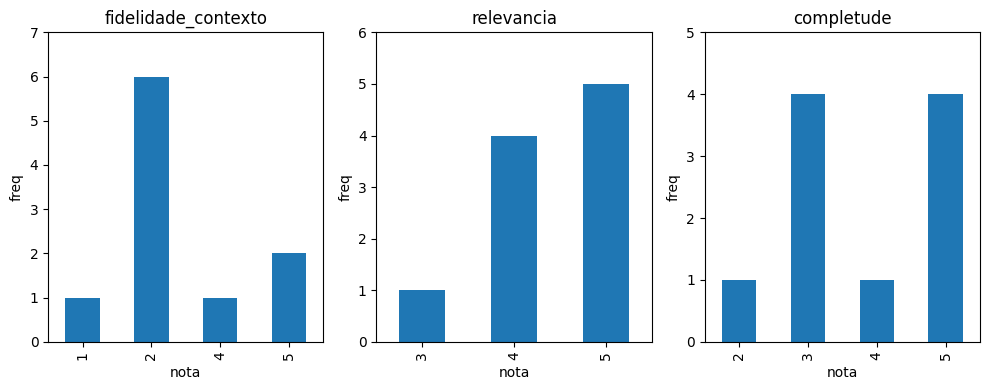

### Médias do LLM-as-a-judge

,fidelidade_contexto,relevancia,completude
media,2.7,4.4,3.8


In [ ]:
plt.figure(figsize=(10, 4))
for i, col in enumerate(["fidelidade_contexto", "relevancia", "completude"], start=1):
    plt.subplot(1, 3, i)
    df_judge[col].value_counts().sort_index().plot(kind="bar")
    plt.title(col)
    plt.xlabel("nota")
    plt.ylabel("freq")
    plt.ylim(0, max(1, df_judge[col].value_counts().max() + 1))

plt.tight_layout()
plt.show()

display(Markdown("### Médias do LLM-as-a-judge"))
display(df_judge[["fidelidade_contexto", "relevancia", "completude"]].mean().to_frame("media").T)

**Análise das métricas de LLM-as-a-Judge**


- O valor da métrica de `fidelidade_contexto` está na média (2.7) pois k=5 pode estar introduzindo ruído e contexto desnecessário para o RAG responder a pergunta (informação demais em alguns casos). A `temperatura=0.2` também pode estar levemente contribuindo para isso com alucionações e dados fora do contexto.

- Entretanto, existe um trade-off: esse excesso de informação pode ser o que está garantindo notas altas em `relevancia` (4.4) e `completude` (3.8)

- Em sistema reais em produção, é muito difícil maximixar todas essas métricas: `fidelidade_contexto`, `relevancia` e `completude`. Dependendo do caso de uso, deve-se ter uma métrica de preferência:


| Domínio de Aplicação | Métrica Prioritária | Justificativa Técnica |
| :--- | :--- | :--- |
| **Jurídico e Compliance** | **Fidelidade ao Contexto** | Erros ou alucinações podem gerar sanções legais. Cada afirmação deve ser rastreável a uma lei ou cláusula exata. |
| **Saúde e Diagnóstico** | **Fidelidade ao Contexto** | A precisão factual é vital para a segurança do paciente. Alucinar dosagens ou protocolos é inaceitável. |
| **Suporte Técnico N1** | **Relevância** | O objetivo principal é resolver a dor do usuário rapidamente. A resposta deve ir direto ao ponto da falha relatada. |
| **Educação (Tutoria)** | **Relevância / Completude** | O foco é o processo de aprendizagem. A resposta deve ser completa o suficiente para explicar o conceito, mas relevante ao nível do aluno. |
| **E-commerce (Vendas)** | **Relevância** | Respostas rápidas e que atendam à intenção de compra são cruciais para evitar que o cliente desista por falta de informação. |

Nesse meu caso de atendimento no e-commerce, faz sentido e é preferível ter uma métrica de relevância maior que as outras.